# DNN — PyTorch (GPU-Accelerated)

## Model: Deep Neural Network (Multi-Layer Perceptron)
- **Dataset**: UCI HAR — 7,352 train / 2,947 test, 561 sensor features
- **Task**: Classify 6 human activities (3 dynamic, 3 static)
- **Framework showcase**: BatchNorm + Dropout + LR scheduling — full regularization toolkit

## GPU Acceleration Strategy
- All tensor ops on CUDA (forward pass, backprop, loss computation)
- `nn.Module` subclass with configurable hidden layers
- Adam optimizer with `ReduceLROnPlateau` scheduler
- float32 on GPU, manual train/val split for early stopping

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.visualization import (plot_confusion_matrix_multiclass,
                                  plot_per_class_f1, plot_training_history)
from utils.metrics import evaluate_classifier
from utils.performance import track_performance, track_inference, get_model_size
from utils.results import build_results_dict, save_results, add_result, print_comparison

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# Configuration
RANDOM_STATE = 113
FRAMEWORK = "PyTorch"
N_CLASSES = 6
BATCH_SIZE = 64
ACTIVITY_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]

# Reproducibility
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load preprocessed UCI HAR
X_train_np, X_test_np, y_train_np, y_test_np, meta = load_processed_data('dnn')

# Convert to GPU tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32, device=device)
y_train = torch.tensor(y_train_np, dtype=torch.long, device=device)
X_test = torch.tensor(X_test_np, dtype=torch.float32, device=device)
y_test = torch.tensor(y_test_np, dtype=torch.long, device=device)

# Train/val split (90/10 from train, matching SK's validation_fraction)
n_val = int(len(X_train) * 0.1)
indices = torch.randperm(len(X_train), device=device)
val_idx, train_idx = indices[:n_val], indices[n_val:]

X_val = X_train[val_idx]
y_val = y_train[val_idx]
X_train_split = X_train[train_idx]
y_train_split = y_train[train_idx]

# DataLoader for mini-batch training
train_dataset = TensorDataset(X_train_split, y_train_split)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("=" * 60)
print(f"[1/9] Data loaded — {FRAMEWORK} DNN")
print("=" * 60)
print(f"  Device: {device} ({torch.cuda.get_device_name(0)})")
print(f"  Train: {X_train_split.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"  Classes: {N_CLASSES} ({', '.join(ACTIVITY_NAMES)})")
print(f"  Batch size: {BATCH_SIZE} ({len(train_loader)} batches/epoch)")
print(f"  GPU memory: {torch.cuda.memory_allocated() / 1e6:.1f} MB")

[1/9] Data loaded — PyTorch DNN
  Device: cuda (NVIDIA GeForce RTX 4090)
  Train: torch.Size([6617, 561]) | Val: torch.Size([735, 561]) | Test: torch.Size([2947, 561])
  Classes: 6 (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING)
  Batch size: 64 (104 batches/epoch)
  GPU memory: 40.1 MB


In [2]:
# Step 2: Simple baseline — single hidden layer, same as SK baseline

# nn.Module lets us define arbitrary architectures (SK's MLPClassifier is more rigid)

print("=" * 60)
print("[2/9] SIMPLE BASELINE DNN")
print("=" * 60)

class SimpleDNN(nn.Module):
    """Simple DNN with configurable hidden layers.

    Args:
        input_dim: Number of input features.
        hidden_sizes: Tuple of hidden layer sizes.
        n_classes: Number of output classes.
    """

    def __init__(self, input_dim, hidden_sizes, n_classes):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_model(model, train_loader, X_val, y_val, n_epochs=200, patience=15, lr=0.001):
    """Train with Adam + early stopping on val accuracy.

    Args:
        model: nn.Module to train.
        train_loader: DataLoader for training batches.
        X_val: Validation features tensor.
        y_val: Validation labels tensor.
        n_epochs: Max training epochs.
        patience: Early stopping patience.
        lr: Learning rate.

    Returns:
        dict with train_loss, val_acc lists and best_epoch.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(n_epochs):
        # Training
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(y_batch)

        avg_loss = epoch_loss / len(train_loader.dataset)
        history['train_loss'].append(avg_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_preds = val_logits.argmax(dim=1)
            val_acc = (val_preds == y_val).float().mean().item()
        history['val_acc'].append(val_acc)

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch + 1
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    # Restore best weights
    model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch
    return history

# Train simple baseline (128,) — same as SK
baseline = SimpleDNN(561, (128,), N_CLASSES).to(device)
history_base = train_model(baseline, train_loader, X_val, y_val, n_epochs=200, patience=15)

# Evaluate on test set
baseline.eval()
with torch.no_grad():
    y_pred_base = baseline(X_test).argmax(dim=1).cpu().numpy()

base_metrics = evaluate_classifier(y_test_np, y_pred_base)

print(f"\n  Architecture: 561 → 128 → 6")
print(f"  Epochs: {len(history_base['train_loss'])} (best at {history_base['best_epoch']})")
print(f"  Final train loss: {history_base['train_loss'][-1]:.4f}")
print(f"  Best val acc: {max(history_base['val_acc']):.4f}")
print(f"\n  Test Results:")
print(f"    Accuracy: {base_metrics['accuracy']:.4f}")
print(f"    Macro F1: {base_metrics['macro_f1']:.4f}")

[2/9] SIMPLE BASELINE DNN

  Architecture: 561 → 128 → 6
  Epochs: 35 (best at 20)
  Final train loss: 0.0007
  Best val acc: 0.9837

  Test Results:
    Accuracy: 0.9393
    Macro F1: 0.9396


[3/9] TRAINING HISTORY


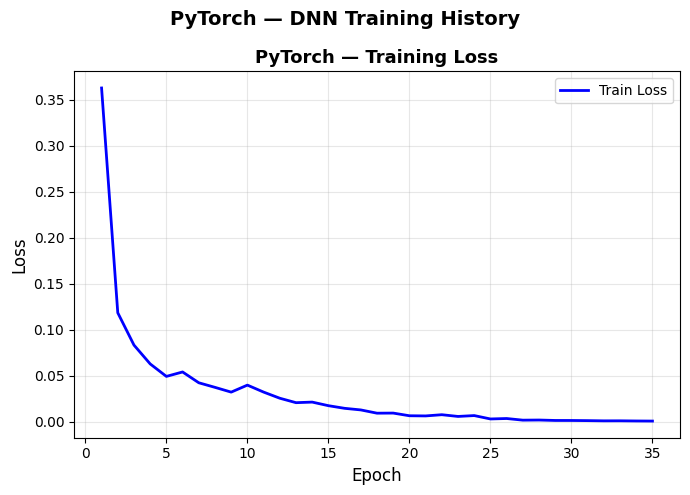

  Epochs: 35
  Loss: 0.3628 → 0.0007
  Val acc: 0.9537 → 0.9837
  Best epoch: 20


In [3]:
# Step 3: Visualize baseline training curves
print("=" * 60)
print("[3/9] TRAINING HISTORY")
print("=" * 60)

plot_training_history(history_base, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history_baseline.png')

print(f"  Epochs: {len(history_base['train_loss'])}")
print(f"  Loss: {history_base['train_loss'][0]:.4f} → {history_base['train_loss'][-1]:.4f}")
print(f"  Val acc: {history_base['val_acc'][0]:.4f} → {max(history_base['val_acc']):.4f}")
print(f"  Best epoch: {history_base['best_epoch']}")

[4/9] SHOWCASE: BATCHNORM + DROPOUT + LR SCHEDULING

  [1/2] Simple DNN (128-64)...
    Epochs: 47 | Acc: 0.9399 | F1: 0.9403

  [2/2] Regularized DNN (128-64, BN+Dropout+LR sched)...
    Epochs: 39 | Acc: 0.9498 | F1: 0.9501


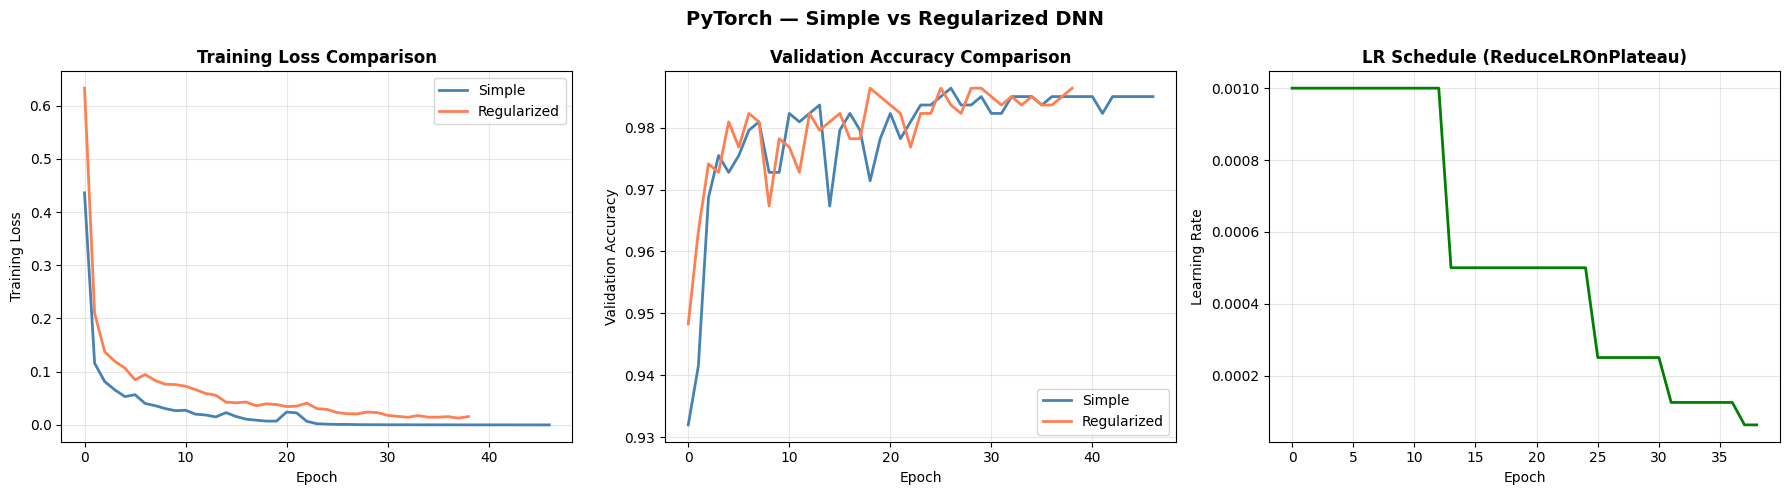


  Model                     Acc       F1   Epochs
  ----------------------------------------------
  Simple (128-64)        0.9399   0.9403       47
  Regularized (128-64)   0.9498   0.9501       39


In [4]:
# Step 4: PT showcase — BatchNorm, Dropout, and LR scheduling

"""
These are PyTorch's regularization toolkit that SK's MLPClassifier lacks:
  - BatchNorm: normalizes activations per mini-batch, stabilizes training
  - Dropout: randomly zeros neurons during training, prevents co-adaptation
  - ReduceLROnPlateau: cuts LR when val acc plateaus, fine-tunes convergence
"""

print("=" * 60)
print("[4/9] SHOWCASE: BATCHNORM + DROPOUT + LR SCHEDULING")
print("=" * 60)


class RegularizedDNN(nn.Module):
    """
    DNN with BatchNorm, Dropout, and configurable architecture.

    Args:
        input_dim: Number of input features.
        hidden_sizes: Tuple of hidden layer sizes.
        n_classes: Number of output classes.
        dropout: Dropout probability (0 = no dropout).
    """

    def __init__(self, input_dim, hidden_sizes, n_classes, dropout=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_regularized(model, train_loader, X_val, y_val, n_epochs=200,
                      patience=20, lr=0.001):
    """
    Train with Adam + ReduceLROnPlateau + early stopping.

    Args:
        model: nn.Module to train.
        train_loader: DataLoader for training batches.
        X_val: Validation features tensor.
        y_val: Validation labels tensor.
        n_epochs: Max training epochs.
        patience: Early stopping patience.
        lr: Initial learning rate.

    Returns:
        dict with train_loss, val_acc, lr_history lists and best_epoch.
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=5
    )

    history = {'train_loss': [], 'val_acc': [], 'lr_history': []}
    best_val_acc = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(n_epochs):
        # Training
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(y_batch)

        avg_loss = epoch_loss / len(train_loader.dataset)
        history['train_loss'].append(avg_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val)
            val_preds = val_logits.argmax(dim=1)
            val_acc = (val_preds == y_val).float().mean().item()
        history['val_acc'].append(val_acc)

        # LR scheduling based on val accuracy
        current_lr = optimizer.param_groups[0]['lr']
        history['lr_history'].append(current_lr)
        scheduler.step(val_acc)

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch + 1
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch
    return history

# Compare: Simple vs Regularized on same (128, 64) architecture
print("\n  [1/2] Simple DNN (128-64)...")
torch.manual_seed(RANDOM_STATE)
simple = SimpleDNN(561, (128, 64), N_CLASSES).to(device)
h_simple = train_model(simple, train_loader, X_val, y_val, n_epochs=200, patience=20)

simple.eval()
with torch.no_grad():
    y_pred_simple = simple(X_test).argmax(dim=1).cpu().numpy()
m_simple = evaluate_classifier(y_test_np, y_pred_simple)
print(f"    Epochs: {len(h_simple['train_loss'])} | Acc: {m_simple['accuracy']:.4f} | F1: {m_simple['macro_f1']:.4f}")

print("\n  [2/2] Regularized DNN (128-64, BN+Dropout+LR sched)...")
torch.manual_seed(RANDOM_STATE)
reg_model = RegularizedDNN(561, (128, 64), N_CLASSES, dropout=0.3).to(device)
h_reg = train_regularized(reg_model, train_loader, X_val, y_val, n_epochs=200, patience=20)

reg_model.eval()
with torch.no_grad():
    y_pred_reg = reg_model(X_test).argmax(dim=1).cpu().numpy()
m_reg = evaluate_classifier(y_test_np, y_pred_reg)
print(f"    Epochs: {len(h_reg['train_loss'])} | Acc: {m_reg['accuracy']:.4f} | F1: {m_reg['macro_f1']:.4f}")

# Plot comparison: training curves + LR schedule
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(h_simple['train_loss'], label='Simple', color='steelblue', linewidth=2)
axes[0].plot(h_reg['train_loss'], label='Regularized', color='coral', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Training Loss Comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val accuracy curves
axes[1].plot(h_simple['val_acc'], label='Simple', color='steelblue', linewidth=2)
axes[1].plot(h_reg['val_acc'], label='Regularized', color='coral', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy Comparison', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LR schedule (regularized only)
axes[2].plot(h_reg['lr_history'], color='green', linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('LR Schedule (ReduceLROnPlateau)', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'{FRAMEWORK} — Simple vs Regularized DNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/showcase_regularization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  {'Model':<20} {'Acc':>8} {'F1':>8} {'Epochs':>8}")
print(f"  {'-'*46}")
print(f"  {'Simple (128-64)':<20} {m_simple['accuracy']:>8.4f} {m_simple['macro_f1']:>8.4f} {len(h_simple['train_loss']):>8}")
print(f"  {'Regularized (128-64)':<20} {m_reg['accuracy']:>8.4f} {m_reg['macro_f1']:>8.4f} {len(h_reg['train_loss']):>8}")

[5/9] ARCHITECTURE SWEEP (REGULARIZED)

  Training: 64 ...
    Acc: 0.9467 | F1: 0.9481 | Params: 36,486 | Epochs: 33

  Training: 128 ...
    Acc: 0.9467 | F1: 0.9478 | Params: 72,966 | Epochs: 38

  Training: 256 ...
    Acc: 0.9413 | F1: 0.9417 | Params: 145,926 | Epochs: 34

  Training: 128-64 ...
    Acc: 0.9498 | F1: 0.9501 | Params: 80,966 | Epochs: 39

  Training: 256-128 ...
    Acc: 0.9603 | F1: 0.9602 | Params: 178,310 | Epochs: 56

  Training: 256-128-64 ...
    Acc: 0.9572 | F1: 0.9571 | Params: 186,310 | Epochs: 41


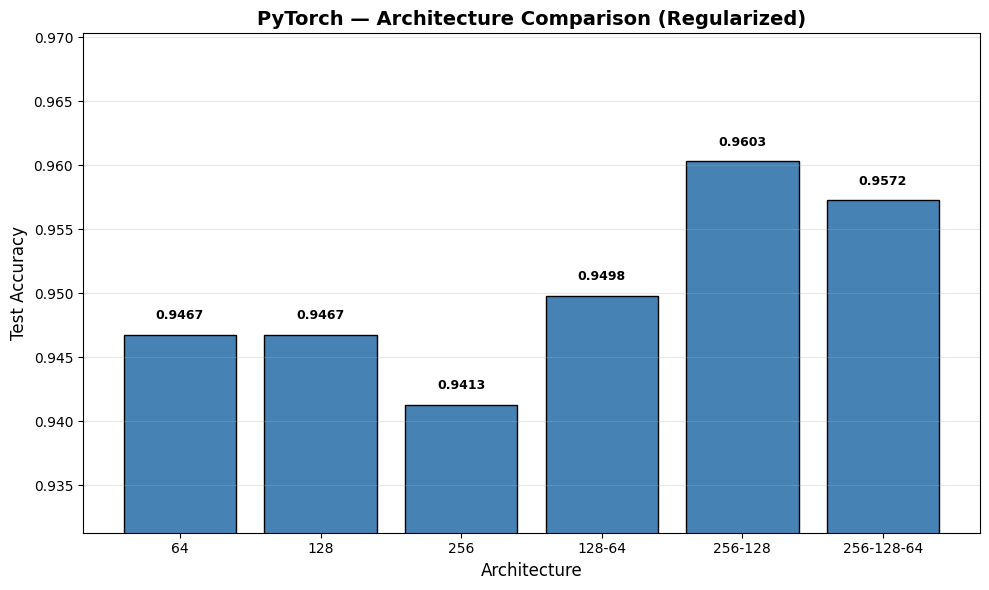


  Architecture          Acc       F1     Params   Epochs
  ----------------------------------------------------
  64                 0.9467   0.9481     36,486       33
  128                0.9467   0.9478     72,966       38
  256                0.9413   0.9417    145,926       34
  128-64             0.9498   0.9501     80,966       39
  256-128            0.9603   0.9602    178,310       56
  256-128-64         0.9572   0.9571    186,310       41

  Best: 256-128 (Acc: 0.9603)


In [5]:
# Step 5: Architecture sweep with regularization
# All architectures use BatchNorm + Dropout + LR scheduling
print("=" * 60)
print("[5/9] ARCHITECTURE SWEEP (REGULARIZED)")
print("=" * 60)

architectures = {
    '64':           (64,),
    '128':          (128,),
    '256':          (256,),
    '128-64':       (128, 64),
    '256-128':      (256, 128),
    '256-128-64':   (256, 128, 64),
}

arch_results = {}

for name, layers in architectures.items():
    print(f"\n  Training: {name} ...")
    torch.manual_seed(RANDOM_STATE)
    model = RegularizedDNN(561, layers, N_CLASSES, dropout=0.3).to(device)
    h = train_regularized(model, train_loader, X_val, y_val, n_epochs=200, patience=20)

    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).argmax(dim=1).cpu().numpy()
    metrics = evaluate_classifier(y_test_np, y_pred)

    n_params = sum(p.numel() for p in model.parameters())

    arch_results[name] = {
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'epochs': len(h['train_loss']),
        'n_params': n_params
    }
    print(f"    Acc: {metrics['accuracy']:.4f} | F1: {metrics['macro_f1']:.4f} | Params: {n_params:,} | Epochs: {len(h['train_loss'])}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
names = list(arch_results.keys())
accs = [arch_results[n]['accuracy'] for n in names]
bars = ax.bar(names, accs, color='steelblue', edgecolor='black')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Architecture', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title(f'{FRAMEWORK} — Architecture Comparison (Regularized)', fontsize=14, fontweight='bold')
ax.set_ylim(min(accs) - 0.01, max(accs) + 0.01)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/architecture_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print(f"\n  {'Architecture':<16} {'Acc':>8} {'F1':>8} {'Params':>10} {'Epochs':>8}")
print(f"  {'-'*52}")
for name in names:
    r = arch_results[name]
    print(f"  {name:<16} {r['accuracy']:>8.4f} {r['macro_f1']:>8.4f} {r['n_params']:>10,} {r['epochs']:>8}")

best_arch = max(arch_results, key=lambda k: arch_results[k]['accuracy'])
print(f"\n  Best: {best_arch} (Acc: {arch_results[best_arch]['accuracy']:.4f})")

[6/9] BEST MODEL — FULL EVALUATION

  Architecture: 561 → 256 → 128 → 6
  Epochs: 56 (best at 36)
  Training time: 13.38s

  Test Metrics:
    Accuracy: 0.9603
    Macro F1: 0.9602


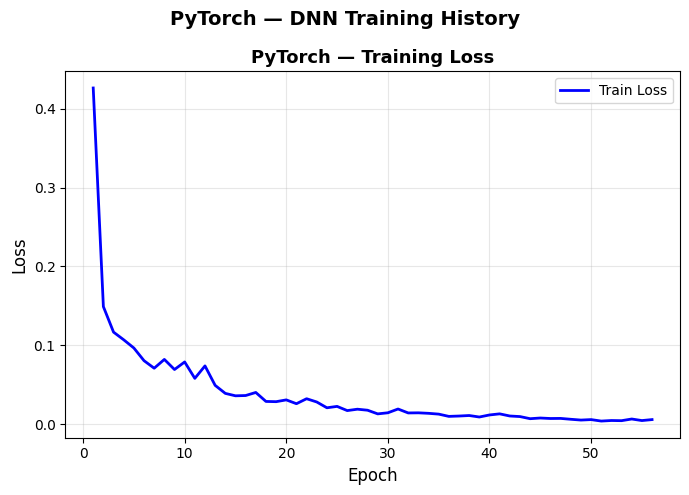

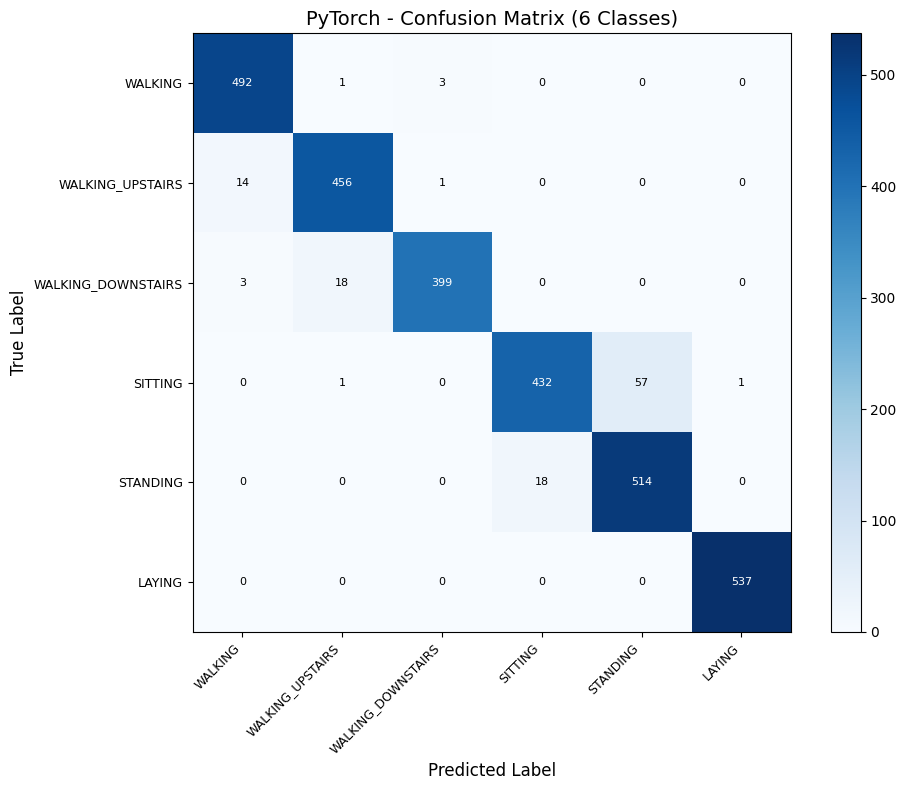

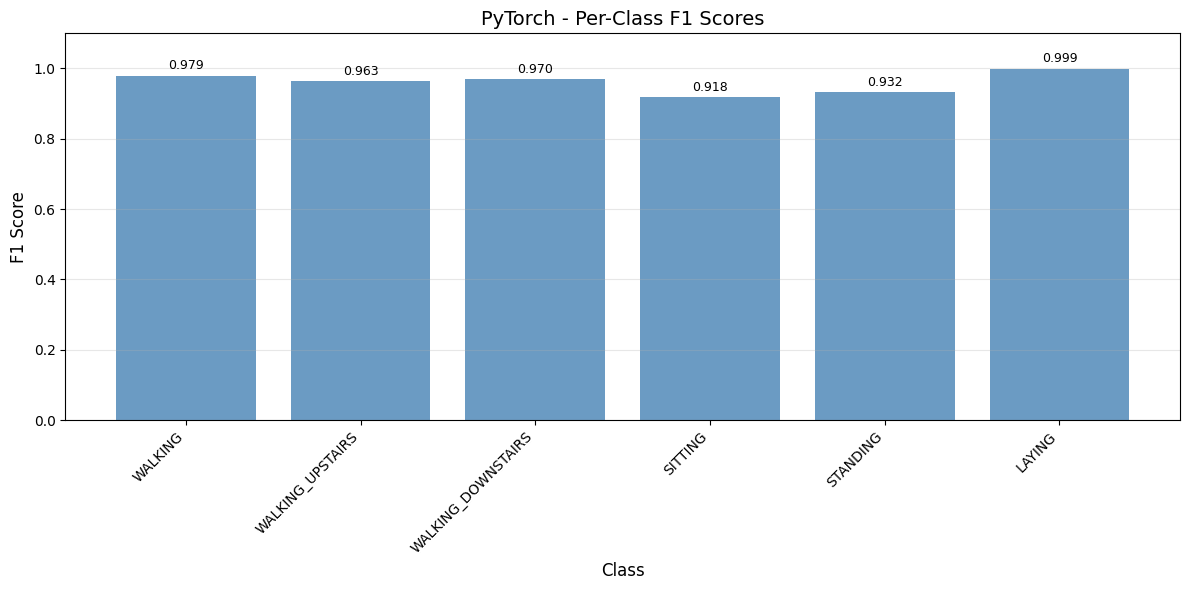

In [6]:
# Step 6: Retrain best architecture (256-128) with full evaluation
print("=" * 60)
print("[6/9] BEST MODEL — FULL EVALUATION")
print("=" * 60)

torch.manual_seed(RANDOM_STATE)
torch.cuda.reset_peak_memory_stats()

best_model = RegularizedDNN(561, (256, 128), N_CLASSES, dropout=0.3).to(device)

with track_performance(gpu=True) as perf:
    h_best = train_regularized(best_model, train_loader, X_val, y_val,
                                n_epochs=200, patience=20)
    torch.cuda.synchronize()

best_model.eval()
with torch.no_grad():
    y_pred = best_model(X_test).argmax(dim=1).cpu().numpy()

metrics = evaluate_classifier(y_test_np, y_pred)

n_params = sum(p.numel() for p in best_model.parameters())

print(f"\n  Architecture: 561 → 256 → 128 → 6")
print(f"  Epochs: {len(h_best['train_loss'])} (best at {h_best['best_epoch']})")
print(f"  Training time: {perf['time']:.2f}s")
print(f"\n  Test Metrics:")
print(f"    Accuracy: {metrics['accuracy']:.4f}")
print(f"    Macro F1: {metrics['macro_f1']:.4f}")

# Training history
plot_training_history(h_best, FRAMEWORK,
                      save_path=f'{RESULTS_DIR}/training_history_best.png')

# Confusion matrix
plot_confusion_matrix_multiclass(y_test_np, y_pred, ACTIVITY_NAMES, FRAMEWORK,
                                  save_path=f'{RESULTS_DIR}/confusion_matrix.png')

# Per-class F1
plot_per_class_f1(y_test_np, y_pred, ACTIVITY_NAMES, FRAMEWORK,
                   save_path=f'{RESULTS_DIR}/per_class_f1.png')

In [7]:
# Step 7: Performance benchmarks
print("=" * 60)
print("[7/9] PERFORMANCE BENCHMARKS")
print("=" * 60)

print(f"\n  Training time: {perf['time']:.2f}s")
print(f"  Memory (CPU): {perf['memory']:.2f} MB")
print(f"  Memory (GPU): {perf['gpu_memory']:.2f} MB")

# Inference benchmark
def predict_fn(X_np):
    X_gpu = torch.tensor(X_np, dtype=torch.float32, device=device)
    with torch.no_grad():
        preds = best_model(X_gpu).argmax(dim=1)
    torch.cuda.synchronize()
    return preds.cpu().numpy()

inference_result = track_inference(predict_fn, X_test_np, n_runs=100)
print(f"\n  Inference ({X_test_np.shape[0]} samples):")
print(f"    Total: {inference_result['total_time']:.4f}s")
print(f"    Per sample: {inference_result['per_sample_us']:.2f} µs")

# Model size — compute from parameter tensors
model_bytes = sum(p.nelement() * p.element_size() for p in best_model.parameters())
model_size = model_bytes
print(f"\n  Model size: {model_size / 1024:.2f} KB")
print(f"  Parameters: {n_params:,}")
print(f"\n  Model Architecture:")
print(best_model)

[7/9] PERFORMANCE BENCHMARKS

  Training time: 13.38s
  Memory (CPU): 0.33 MB
  Memory (GPU): 63.27 MB

  Inference (2947 samples):
    Total: 0.0012s
    Per sample: 0.42 µs

  Model size: 696.52 KB
  Parameters: 178,310

  Model Architecture:
RegularizedDNN(
  (net): Sequential(
    (0): Linear(in_features=561, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [8]:
# Step 8: Save results + cross-framework comparison
print("=" * 60)
print("[8/9] SAVE RESULTS")
print("=" * 60)

test_metrics = {
    'accuracy': metrics['accuracy'],
    'macro_f1': metrics['macro_f1']
}

results = build_results_dict(
    framework=FRAMEWORK,
    model_name='DNN',
    test_metrics=test_metrics,
    perf=perf,
    inference_stats=inference_result,
    model_size=model_size,
    architecture='561-256(BN+DO)-128(BN+DO)-6',
    n_params=n_params,
    epochs=len(h_best['train_loss']),
    best_epoch=h_best['best_epoch'],
    activation='relu',
    dropout=0.3,
    batch_norm=True,
    lr_scheduler='ReduceLROnPlateau',
    early_stopping=True
)

save_results(results, f'{RESULTS_DIR}/dnn.json')
print(f"\n  Results saved to {RESULTS_DIR}/dnn.json")

# Add to cross-framework comparison
add_result('dnn', results)
print_comparison('dnn')

[8/9] SAVE RESULTS
    Results saved to: results/dnn.json\metrics.json

  Results saved to results/dnn.json
    Added 'PyTorch' to C:\Users\Max\Desktop\Coding\.Projects\2026\ml-framework-comparisons\data\results\dnn.json
    Frameworks recorded: 3/4

CROSS-FRAMEWORK COMPARISON: DNN
Metric                                         Scikit-Learn                   TensorFlow                      PyTorch
---------------------------------------------------------------------------------------------------------------------
model                                                   DNN                          DNN                          DNN
training_time                                        2.42 s                       9.14 s                      13.38 s
inference_time_per_sample_us                        0.65 µs                     31.68 µs                      0.42 µs
model_size_bytes                                   314.8 KB                     316.3 KB                     696.5 KB
peak_memo

In [9]:
# Step 9: MLflow Tracking + Model Export (Deployment Prep)
# PyTorch won DNN accuracy (96.03%) — staging for deployment

import mlflow
import mlflow.pytorch
from mlflow.models import infer_signature
import torch

print("=" * 60)
print("[9/9] MLflow Tracking + Model Export")
print("=" * 60)

# best_model already trained from Cell 6 (256-128 RegularizedDNN)

# MLflow experiment logging
mlflow.set_experiment("dnn")

with mlflow.start_run(run_name="pytorch-dnn-256-128"):
    # Log hyperparameters
    mlflow.log_params({
        'architecture': '561-256-128-6',
        'activation': 'relu',
        'dropout': 0.3,
        'batch_norm': True,
        'optimizer': 'adam',
        'lr_scheduler': 'ReduceLROnPlateau',
        'batch_size': BATCH_SIZE,
        'early_stopping_patience': 20,
        'random_state': RANDOM_STATE,
        'framework': FRAMEWORK,
        'dataset': 'uci-har',
        'n_train_samples': X_train.shape[0],
        'n_features': X_train.shape[1]
    })

    # Log metrics
    mlflow.log_metrics({
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
        'training_time_s': perf['time'],
        'inference_us_per_sample': inference_result['per_sample_us'],
        'model_size_bytes': model_size,
        'peak_memory_gpu_mb': perf['gpu_memory'],
        'n_params': n_params,
        'epochs': len(h_best['train_loss']),
        'best_epoch': h_best['best_epoch']
    })

    # Log model with signature
    # Move to CPU for serving compatibility
    best_model_cpu = best_model.cpu()
    best_model_cpu.eval()
    sample_input = torch.tensor(X_test_np[:5], dtype=torch.float32)
    with torch.no_grad():
        sample_output = best_model_cpu(sample_input).numpy()
    signature = infer_signature(X_test_np[:5], sample_output)
    mlflow.pytorch.log_model(best_model_cpu, name="dnn-uci-har", signature=signature)

    # Log visualizations as artifacts
    mlflow.log_artifacts("results/", artifact_path="visualizations")

    run_id = mlflow.active_run().info.run_id
    print(f"\n  Run ID:     {run_id}")
    print(f"  Experiment: dnn")

# Export model locally (PyTorch native format)
torch.save(best_model.state_dict(), f'{RESULTS_DIR}/dnn_model.pth')
print(f"\n  Model exported: {RESULTS_DIR}/dnn_model.pth")

# Also save full model for simpler loading
torch.save(best_model, f'{RESULTS_DIR}/dnn_model_full.pt')
print(f"  Full model: {RESULTS_DIR}/dnn_model_full.pt")
print(f"  Ready for deployment staging")

[9/9] MLflow Tracking + Model Export


2026/03/18 20:37:58 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/18 20:37:58 INFO mlflow.store.db.utils: Updating database tables
2026/03/18 20:37:58 INFO mlflow.tracking.fluent: Experiment with name 'dnn' does not exist. Creating a new experiment.
2026/03/18 20:37:59 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/18 20:37:59 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please u


  Run ID:     aa31927a343e4c4a848a8938508f689f
  Experiment: dnn

  Model exported: results/dnn_model.pth
  Full model: results/dnn_model_full.pt
  Ready for deployment staging
